### To make a complete system, first we make them in ipynb and later make corresponding python .py files for each

#### AI Tutor is a multi-agent agentic system that follows multi-agent architecture.

##### We add multiple specialized agents to the AI Tutor that works autonomouly parallely or sequentially based upon the requirements to reach/achieve the goal. Supervisor being at the top makes the goal into sub-goals and provide the sub-goal to corresponding agents based upon the specialization

##### All the necessary imports are:

In [136]:
from langchain_core.tools import tool
from langchain_tavily import TavilySearch
from langchain_groq import ChatGroq
from langchain_community.document_loaders import PyPDFLoader
from langchain_core.prompts import PromptTemplate, ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser, PydanticOutputParser
from pydantic import BaseModel, Field
from typing import Literal, TypedDict, Optional, List, Annotated
from langchain_ollama import OllamaEmbeddings
from langchain_core.messages import HumanMessage, SystemMessage, ToolMessage, AIMessage, BaseMessage
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langgraph.graph import StateGraph, START, END
from langgraph_supervisor import create_supervisor
from langgraph.prebuilt import create_react_agent
from langgraph.checkpoint.memory import MemorySaver
from langgraph.checkpoint.sqlite import SqliteSaver
import sqlite3
from langgraph.graph.message import add_messages
from langgraph.types import Command, Interrupt
from dotenv import load_dotenv
import os
import json

In [137]:
load_dotenv()

True

### Supervisor and Workers:- 

##### We need to make a supervisor agent where all the workers agent that are going to work and their use are given to the supervisor using prompt so that it can make reasoning and then handsoff the corresponding agent.

##### The supervisor should route the task to the corresponding agent in such a way that the whole task could be done by the agent in and no other agent's capable work should be given to the agent. Such prompt should be given to the supervisor agent.

##### Each agent will get the task that only belongs to it and then when the agent does its work then the agent will change the state due to which the supervisor can get all the changes done by the agent and go for the next job to delegate.

##### It's just like the Orchestrator.

### tools

In [138]:
llm = ChatGroq(
    api_key=os.getenv("api_key"),
    model="meta-llama/llama-4-scout-17b-16e-instruct"
)

tavily_research_tool = TavilySearch(max_results=3, include_answer= True, search_depth= "advanced", auto_parameters=True)
tavily_research_tool.invoke({"query" : "What is llm?"})

{'query': 'What is llm?',
 'response_time': 2.26,
 'follow_up_questions': None,
 'answer': 'A large language model (LLM) is a powerful AI trained on vast data to understand and generate human language. It uses transformer neural networks for context and flexibility in tasks like text and code generation. LLMs are highly adaptable for various applications.',
 'images': [],
 'results': [{'url': 'https://www.elastic.co/what-is/large-language-models',
   'title': 'Understanding large language models',
   'content': "At its core, a large language model (LLM) is a model trained using deep learning algorithms and capable of a broad range ofnatural language processing (NLP)tasks, such as sentiment analysis, conversational question answering, text translation, classification, and generation. An LLM is a type of neural network (NN) that specifically uses transformer architectures, which are models designed to detect dependencies between different parts of a sequence of data, regardless of their 

In [132]:
os.getenv("model")

'llama-3.3-70b-versatile'

In [23]:
tools = [tavily_research_tool]

tools_by_name = {tool.name : tool for tool in tools}
print(tools_by_name)
llm_with_tools = llm.bind_tools([tavily_research_tool])

res = llm_with_tools.invoke([SystemMessage(content="think that you are an AI research agent and you have to make a decision to use the llm itself for answering or usng the correct tool among the available tools with all the approproate args required to it") ,"Who is the current pm of nepal?"])
print(res)
# print(f"Content:- {res.content}\n{'*'*140}\nReasoning:- {res.additional_kwargs['reasoning_content']}\n{'*'*140}\nTool Calls:- {res.tool_calls}\n{'*'*140}\n")

if res.content == "":
    res = tools_by_name[res.tool_calls[0]['name']].invoke(res.tool_calls[0])
    print(res)

{'tavily_search': TavilySearch(auto_parameters=True, search_depth='advanced', max_results=3, include_answer=True, api_wrapper=TavilySearchAPIWrapper(tavily_api_key=SecretStr('**********'), api_base_url=None))}
content='' additional_kwargs={'reasoning_content': 'The user asks: "Who is the current pm of nepal?" Need up-to-date info. As of March 2026? Let\'s recall. Nepal\'s prime minister as of 2023 was Pushpa Kamal Dahal (Prachanda) served until Dec 2022? Actually timeline: In 2021, Sher Bahadur Deuba served until July 2022. Then Pushpa Kamal Dahal became PM in December 2022. He served until? He resigned in early 2023? Actually he resigned in Jan 2023 after losing confidence. Then Deuba again? Wait check: In 2023, Nepal had political instability. As of 2023, the PM was Pushpa Kamal Dahal (Prachanda) after coalition with Nepali Congress? I need current as of 2026. Likely there have been elections. Might be a new PM. Better to use search tool for latest info.\n\nThus need to use tavily_se

In [24]:
# making dictionary for each of the agents tool

# research agent
research_tools = [tavily_research_tool]
research_tools_by_name = {tool.name : tool for tool in research_tools}

# task_specific_agent
materials_tools = []
materials_tools_by_name = {tool.name : tool for tool in materials_tools}

#rag_agent
rag_tools = []
rag_tools_by_name = {tool.name : tool for tool in rag_tools}

# youtube_agent
youtube_tools = []
youtube_tools_by_name = {tool.name : tool for tool in youtube_tools}

### LLM for each agents with tools binded to it

In [25]:
llm = ChatGroq(model= os.getenv("model"), api_key=os.getenv("api_key"))
research_agent_with_tool =  llm.bind_tools(research_tools)
rag_agent_with_tool = llm.bind_tools(rag_tools)
youtube_agent_with_tool = llm.bind_tools(youtube_tools)
task_agent_with_tool = llm.bind_tools(materials_tools)


In [91]:
# BaseModels

class Task(BaseModel):
    '''contains information of each step of the plan'''
    id : int = Field(description="id of the step")
    goal : str = Field(description="goal that the user needs to reach after reding the task's answer")
    research_flag : bool = Field("True if research tool is required and False if not")

task_schema = PydanticOutputParser(pydantic_object=Task)

class Goal(BaseModel):
    '''contains the goal for the particualr agent with name of the agent'''
    # title : str = Field(description = "name or title based upon the user query")
    id : str = Field(description = "id of the agent in string")
    agent : Literal['Researcher', 'RAG', 'TaskSpecific', 'YoutubeAgent', 'END'] = Field(description="one specific agent that is to be choosen for the work")
    sub_goal : str = Field(description = "goal that is provided the to the specific one agent")

sub_goal_schema = PydanticOutputParser(pydantic_object=Goal)

class RAG_agent_type(BaseModel):
    pass


class Youtube_agent_type(BaseModel):
    pass


class Task_specific_type(BaseModel):
    pass


In [141]:
# Research Graph
class ResearchState(TypedDict):
    # Sub-goal given by the supervisor
    sub_goal : str
    # plan made by the researcher agent
    agent_plan : list[Task]
    # explaination done by agent (either toolMessage or the AiMessage)
    agent_explain : Annotated[list[str], add_messages]
    # key points covered by this agent
    key_points : Annotated[list[str], add_messages]


# MaterialGraph (Q/A_and_flashcards and study planner))
class MaterialsState(TypedDict):
    pass

class RAGState(TypedDict):
    pass

class YoutubeState(TypedDict):
    pass

# Main State
class State(TypedDict):
    goal : str
    title : str
    need_RAG : bool
    agent_id : Annotated[list[str], add_messages]
    Researcher : ResearchState
    YoutubeAgent : Youtube_agent_type
    TaskSpecific : Task_specific_type


In [28]:
def Planner(state : ResearchState):
    goal = state['sub_goal']
    # prompt = PromptTemplate(template="goal : {sub_goal} \n\n{format}", input_variables=['sub_goal'], partial_variables={"format" : task_schema.get_format_instructions()})
    prompt = ChatPromptTemplate.from_messages([
        ("system", """You as an excellent planner agent that can generate a beautiful productive plan to give to the worker agents to execute on the basis of your plan. Workers agents will explain based on you plan so make the plan good. 
         Total number of steps must be less than 7. Return in pure JSON format\n
        {task}"""),
        ("human", "Goal : {goal}")]).partial(task = task_schema.get_format_instructions())
    chain = prompt | llm
    res = chain.invoke({'goal' : goal})
    content = res.content.replace("```json", "").replace("```", "").strip()
    # content = json.loads(res)
    steps = json.loads(content)
    state['agent_plan'] = steps
    return {'agent_plan' : steps}


In [29]:
Planner(ResearchState(sub_goal="clear explaination of Self-attention"))

{'agent_plan': [{'id': 1,
   'goal': 'Understand the concept of Self-attention',
   'research_flag': True},
  {'id': 2,
   'goal': 'Learn the mathematical formulation of Self-attention',
   'research_flag': True},
  {'id': 3,
   'goal': 'Visualize the Self-attention mechanism through diagrams or animations',
   'research_flag': False},
  {'id': 4,
   'goal': 'Implement a simple Self-attention model using a deep learning framework',
   'research_flag': True},
  {'id': 5,
   'goal': 'Compare and contrast Self-attention with other attention mechanisms',
   'research_flag': True},
  {'id': 6,
   'goal': 'Apply Self-attention to a real-world problem or a case study',
   'research_flag': False}]}

In [30]:
def Researcher(state : ResearchState):

    plan = state['agent_plan']
    explaination = []
    prompt = ChatPromptTemplate.from_messages([
        ('system', """You are a **Research and Explanation Worker Agent**.

        You will receive **one task at a time** from the supervisor.
         
        Your objective is to **produce the content necessary to accomplish the goal of the task**.

        ---

        ## Goal-Driven Behavior

        Carefully read the goal and determine:

        * what information is needed
        * what type of explanation is required
        * what level of detail is appropriate

        Your explanation should **adapt to the goal**.
        Do not follow a fixed structure such as "definition, intuition, why needed".

        Examples:

        * If the goal asks for a **definition**, provide a clear definition.
        * If the goal asks for a **mathematical formulation**, present formulas and explanation.
        * If the goal asks for a **numeric example**, show the computation steps.
        * If the goal asks for a **summary**, provide a concise summary.

        Only include information that **directly helps achieve the goal**.

        ---

        ## Scope Control

        Focus strictly on the current task.

        Do NOT:

        * explain unrelated concepts
        * anticipate future steps
        * expand beyond what the goal requires

        If another concept must be referenced, mention it briefly without explaining it.

        ---

        ## Research Rule

        If **research_flag is TRUE**:
        Use the research tool to gather relevant information before writing the explanation.

        If **research_flag is FALSE**:
        Use internal knowledge only.

        ---

        ## Output Requirement

        Produce a **clear explanation or content that directly satisfies the goal**.

        Do not use forced section headings or predefined templates.

        The explanation should be concise, relevant, and aligned with the task objective."""),
        ('human', "task : {task}")
    ])

    chain = prompt | research_agent_with_tool
    for step in plan:
        result = chain.invoke({'task' : step})
        if(result.content == ""):
            # tool calling should be done
            tool_name = result.tool_calls[0]
            tool_response = tools_by_name[tool_name['name']].invoke(tool_name)
            answer = json.loads(tool_response.content)
            explaination.append(answer['answer'])
        else:
            explaination.append(result.content)

    return {'agent_explain' : explaination}

In [31]:
Researcher({'agent_plan': [{'id': 1, 'goal': 'Introduce the general idea of attention in neural networks and why it is needed for handling variable‑length context.', 'research_flag': True}, {'id': 2, 'goal': 'Define self‑attention specifically, describing how each token in a sequence attends to every other token, including itself.', 'research_flag': False}, {'id': 3, 'goal': 'Present the core mathematical formulation (queries, keys, values, dot‑product similarity, scaling, softmax, and weighted sum) with clear notation.', 'research_flag': False}, {'id': 4, 'goal': 'Provide a step‑by‑step numeric example on a short sentence to illustrate how attention scores are computed and applied.', 'research_flag': False}, {'id': 5, 'goal': 'Explain multi‑head self‑attention, showing how multiple attention subspaces are concatenated and projected.', 'research_flag': False}, {'id': 6, 'goal': 'Summarize the advantages of self‑attention (parallelism, long‑range dependency capture) and its role in Transformer architectures.', 'research_flag': False}]})

{'agent_explain': ['Attention mechanisms in neural networks handle variable-length context by dynamically weighting input elements, allowing efficient processing of sequences of different lengths. This is achieved through learnable weights that adapt to each input sequence.',
  'Self-attention is a mechanism in neural networks that allows each token in a sequence to attend to every other token, including itself. This is achieved by computing attention weights based on the interactions between each pair of tokens. The process can be broken down into several steps:\n\n1. **Token Representation**: Each token in the input sequence is represented as a vector, often obtained by embedding the token into a high-dimensional space.\n\n2. **Query, Key, and Value Vectors**: For each token, three vectors are computed: a query vector, a key vector, and a value vector. These vectors are typically obtained by applying different linear transformations to the token representation.\n\n3. **Attention Weig

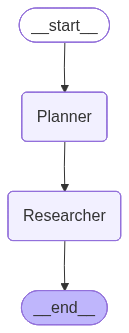

In [32]:
researchGraph = StateGraph(ResearchState)

researchGraph.add_node("Planner", Planner)
researchGraph.add_node("Researcher", Researcher)

researchGraph.add_edge(START, "Planner")
researchGraph.add_edge("Planner", "Researcher")
researchGraph.add_edge("Researcher", END)

ResearcherSubGraph = researchGraph.compile()
ResearcherSubGraph

In [33]:
ResearcherSubGraph.invoke({'sub_goal' : "explain self sttention clearly"})

{'sub_goal': 'explain self sttention clearly',
 'agent_plan': [{'id': 1,
   'goal': 'Understand the concept of self-attention',
   'research_flag': True},
  {'id': 2,
   'goal': 'Explain the mechanism of self-attention in neural networks',
   'research_flag': False},
  {'id': 3,
   'goal': 'Describe the benefits of using self-attention in deep learning models',
   'research_flag': True},
  {'id': 4,
   'goal': 'Provide examples of self-attention in real-world applications',
   'research_flag': False},
  {'id': 5,
   'goal': 'Discuss the limitations and challenges of self-attention',
   'research_flag': True},
  {'id': 6,
   'goal': 'Summarize the key points of self-attention',
   'research_flag': False}],
 'agent_explain': [HumanMessage(content='Self-attention is a mechanism in deep learning that allows models to weigh different parts of an input sequence relative to each other. It is a key component of transformer architectures, enabling parallel processing and efficient training of l

In [34]:
def MiniSuervisor(state : MaterialsState):
    pass

def StudyPlanner(state : MaterialsState):
    pass

def QAandFlashCards(state : MaterialsState):
    pass

def SubAgentSelection(state : MaterialsState):
    if 1:
        return "QAandFlashCards"
    
    elif 2:
        return "StudyPlanner"
    
    elif 3:
        return "END"

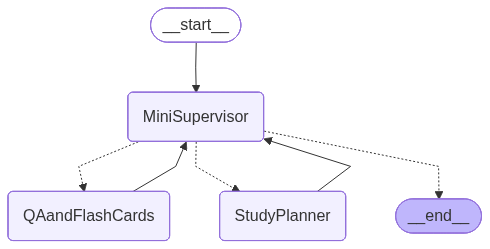

In [35]:
subGraph = StateGraph(State)
subGraph.add_node("MiniSupervisor", MiniSuervisor)
subGraph.add_node("StudyPlanner", StudyPlanner)
subGraph.add_node("QAandFlashCards", QAandFlashCards)

subGraph.add_edge(START, "MiniSupervisor")
subGraph.add_conditional_edges("MiniSupervisor", SubAgentSelection,{"QAandFlashCards" : "QAandFlashCards", "StudyPlanner" : "StudyPlanner"})
subGraph.add_edge("QAandFlashCards", "MiniSupervisor")
subGraph.add_edge("StudyPlanner", "MiniSupervisor")
subGraph.add_edge("MiniSupervisor", END)

subSystem = subGraph.compile()

subSystem

In [36]:
a = {'sub_goal': 'explain self sttention clearly',
 'agent_plan': [{'id': 1,
   'goal': 'Introduce the concept of attention in neural networks and its purpose in focusing on relevant information.',
   'research_flag': False},
  {'id': 2,
   'goal': 'Explain the query‑key‑value formulation that underlies self‑attention, defining each component and how they interact.',
   'research_flag': False},
  {'id': 3,
   'goal': 'Show a step‑by‑step numerical example of computing attention scores, applying the softmax, and obtaining the weighted sum.',
   'research_flag': False},
  {'id': 4,
   'goal': 'Describe multi‑head attention, why multiple heads are used, and how their outputs are concatenated and projected.',
   'research_flag': False},
  {'id': 5,
   'goal': 'Summarize the advantages of self‑attention (parallelism, long‑range dependencies) and its role in Transformer architectures.',
   'research_flag': False}],
 'agent_explain': [HumanMessage(content='Attention is a mechanism that lets a neural network dynamically weigh different parts of its input when producing an output, rather than treating every element as equally important. By computing a set of relevance scores (often called “attention weights”) between a query representation and a collection of key–value pairs derived from the data, the model can amplify information that is most pertinent to the current task and suppress what is less useful. This selective focus enables networks—especially sequence models like Transformers—to capture long‑range dependencies, handle variable‑length inputs, and produce more accurate predictions, because each decision is informed primarily by the pieces of data that matter most in that context. In short, attention helps neural networks concentrate on the relevant information while ignoring the irrelevant.', additional_kwargs={}, response_metadata={}, id='6123b968-8ad6-4ae5-a23c-1ffbf2621012'),
  HumanMessage(content='Self‑attention computes a new representation for each token by letting that token **query** information from all other tokens (including itself).  \nThe whole operation can be written as a series of matrix multiplications that involve three learned projections of the input sequence:\n\n\\[\n\\begin{aligned}\nQ &= X\\,W_Q \\qquad &\\text{(queries)}\\\\\nK &= X\\,W_K \\qquad &\\text{(keys)}\\\\\nV &= X\\,W_V \\qquad &\\text{(values)}\n\\end{aligned}\n\\]\n\n* **\\(X\\)** – the input matrix of shape \\((n, d_{\\text{model}})\\), where \\(n\\) is the number of tokens (or positions) and \\(d_{\\text{model}}\\) is the hidden dimension.  \n* **\\(W_Q, W_K, W_V\\)** – learned weight matrices of shape \\((d_{\\text{model}}, d_k)\\) (or \\((d_{\\text{model}}, d_v)\\) for values). They linearly project each token into three distinct sub‑spaces:\n  * **Query vectors** \\(q_i\\) describe what token \\(i\\) is looking for.\n  * **Key vectors** \\(k_j\\) describe what each token \\(j\\) offers.\n  * **Value vectors** \\(v_j\\) hold the actual content that will be passed on if a token is attended to.\n\n---\n\n### Interaction: attention scores and weighted sum  \n\nFor every pair of tokens \\((i, j)\\) we compute a similarity score by the dot product of their query and key:\n\n\\[\n\\alpha_{ij} = \\frac{q_i \\cdot k_j}{\\sqrt{d_k}}\n\\]\n\nThe division by \\(\\sqrt{d_k}\\) (the **scaling factor**) prevents the dot‑product magnitude from growing with the dimensionality, which would push the softmax into regions with extremely small gradients.\n\nThese raw scores are turned into a probability distribution over the \\(n\\) tokens with a softmax:\n\n\\[\n\\tilde{\\alpha}_{ij}= \\operatorname{softmax}_j(\\alpha_{ij}) \n= \\frac{\\exp(\\alpha_{ij})}{\\sum_{l=1}^{n}\\exp(\\alpha_{il})}\n\\]\n\n\\(\\tilde{\\alpha}_{ij}\\) tells how much token \\(i\\) should attend to token \\(j\\).\n\nFinally, each token’s output is the weighted sum of the value vectors, using the attention weights:\n\n\\[\n\\text{output}_i = \\sum_{j=1}^{n} \\tilde{\\alpha}_{ij}\\, v_j\n\\]\n\nIn matrix form this becomes the familiar **scaled dot‑product attention**:\n\n\\[\n\\text{Attention}(Q,K,V)=\\operatorname{softmax}\\!\\left(\\frac{QK^{\\top}}{\\sqrt{d_k}}\\right)V\n\\]\n\n---\n\n### Summary of components  \n\n| Symbol | Meaning | Shape (for one head) |\n|--------|---------|----------------------|\n| \\(X\\) | Input token embeddings | \\((n, d_{\\text{model}})\\) |\n| \\(W_Q, W_K, W_V\\) | Linear projection matrices (learned) | \\((d_{\\text{model}}, d_k)\\) or \\((d_{\\text{model}}, d_v)\\) |\n| \\(Q, K, V\\) | Projected queries, keys, values | \\((n, d_k)\\) (or \\(d_v\\) for \\(V\\)) |\n| \\(QK^{\\top}\\) | Pairwise similarity matrix | \\((n, n)\\) |\n| \\(\\operatorname{softmax}(\\cdot)\\) | Normalizes similarities into attention weights | \\((n, n)\\) |\n| \\( \\text{Attention}(Q,K,V) \\) | Final output after weighting values | \\((n, d_v)\\) |\n\nThe query‑key‑value formulation thus lets each position gather information from the whole sequence, with the learned projections determining **what** is queried, **what** can be matched, and **what** is transmitted. This mechanism is the core of the Transformer’s self‑attention layer.', additional_kwargs={}, response_metadata={}, id='957f3ebb-cbc0-4e82-8300-6678ddd80cc5'),
  HumanMessage(content='**Step‑by‑step numerical example of scaled dot‑product attention**\n\nWe will work with a tiny toy example so every arithmetic step can be shown clearly.\n\n| dimension | 2 (so vectors are 2‑D) |\n|----------|------------------------|\n| number of keys / values | 3 (\u202f\\(k_1,k_2,k_3\\)\u202f) |\n| scaling factor | \\(\\frac{1}{\\sqrt{d}}\\) with \\(d=2\\) → \\(\\frac{1}{\\sqrt{2}}\\approx0.7071\\) |\n\n---\n\n### 1. Define the query, keys and values  \n\n\\[\n\\mathbf{q}= \\begin{bmatrix}1 \\\\ 0\\end{bmatrix},\n\\qquad\n\\mathbf{k}_1=\\begin{bmatrix}1 \\\\ 1\\end{bmatrix},\n\\quad\n\\mathbf{k}_2=\\begin{bmatrix}0 \\\\ 2\\end{bmatrix},\n\\quad\n\\mathbf{k}_3=\\begin{bmatrix} -1 \\\\ 0\\end{bmatrix}\n\\]\n\n\\[\n\\mathbf{v}_1=\\begin{bmatrix}1 \\\\ 2\\end{bmatrix},\n\\quad\n\\mathbf{v}_2=\\begin{bmatrix}0 \\\\ 1\\end{bmatrix},\n\\quad\n\\mathbf{v}_3=\\begin{bmatrix}2 \\\\ 0\\end{bmatrix}\n\\]\n\n---\n\n### 2. Compute raw attention scores (dot products)\n\n\\[\ns_i = \\mathbf{q}^\\top \\mathbf{k}_i\n\\]\n\n| \\(i\\) | \\(\\mathbf{q}^\\top\\mathbf{k}_i\\) | raw score \\(s_i\\) |\n|------|-------------------------------|-------------------|\n| 1 | \\([1,0]\\cdot[1,1]=1\\) | \\(s_1 = 1\\) |\n| 2 | \\([1,0]\\cdot[0,2]=0\\) | \\(s_2 = 0\\) |\n| 3 | \\([1,0]\\cdot[-1,0]=-1\\) | \\(s_3 = -1\\) |\n\n---\n\n### 3. Scale the scores  \n\n\\[\n\\hat{s}_i = \\frac{s_i}{\\sqrt{d}} = s_i \\times 0.7071\n\\]\n\n| \\(i\\) | \\(\\hat{s}_i\\) |\n|------|--------------|\n| 1 | \\(1 \\times 0.7071 = 0.7071\\) |\n| 2 | \\(0 \\times 0.7071 = 0\\) |\n| 3 | \\(-1 \\times 0.7071 = -0.7071\\) |\n\n---\n\n### 4. Apply the softmax to obtain attention weights  \n\n\\[\n\\alpha_i = \\frac{e^{\\hat{s}_i}}{\\sum_{j=1}^{3} e^{\\hat{s}_j}}\n\\]\n\nFirst compute the exponentials:\n\n| \\(i\\) | \\(e^{\\hat{s}_i}\\) |\n|------|-------------------|\n| 1 | \\(e^{0.7071}\\approx 2.028\\) |\n| 2 | \\(e^{0}\\;=1\\) |\n| 3 | \\(e^{-0.7071}\\approx 0.493\\) |\n\nSum of exponentials: \\(2.028 + 1 + 0.493 = 3.521\\).\n\nNow the normalized weights:\n\n| \\(i\\) | \\(\\alpha_i = \\frac{e^{\\hat{s}_i}}{3.521}\\) |\n|------|-------------------------------------------|\n| 1 | \\(\\frac{2.028}{3.521}\\approx0.576\\) |\n| 2 | \\(\\frac{1}{3.521}\\approx0.284\\) |\n| 3 | \\(\\frac{0.493}{3.521}\\approx0.140\\) |\n\nCheck: \\(0.576+0.284+0.140 \\approx 1.000\\).\n\n---\n\n### 5. Compute the weighted sum of the values  \n\n\\[\n\\mathbf{o}= \\sum_{i=1}^{3} \\alpha_i \\mathbf{v}_i\n\\]\n\nDo the multiplication for each component:\n\n*For the first component*  \n\n\\[\no_1 = 0.576\\cdot 1 \\;+\\; 0.284\\cdot 0 \\;+\\; 0.140\\cdot 2\n     = 0.576 + 0 + 0.280 = 0.856\n\\]\n\n*For the second component*  \n\n\\[\no_2 = 0.576\\cdot 2 \\;+\\; 0.284\\cdot 1 \\;+\\; 0.140\\cdot 0\n     = 1.152 + 0.284 + 0 = 1.436\n\\]\n\nThus the final attention output vector is\n\n\\[\n\\boxed{\\mathbf{o}= \\begin{bmatrix}0.856 \\\\ 1.436\\end{bmatrix}}\n\\]\n\n---\n\n### Recap of the whole pipeline\n\n1. **Dot‑product** of query with each key → raw scores \\([1,0,-1]\\).  \n2. **Scale** by \\(1/\\sqrt{d}\\) → \\([0.7071,0,-0.7071]\\).  \n3. **Softmax** → attention weights \\([0.576,0.284,0.140]\\).  \n4. **Weighted sum** of the value vectors using those weights → output \\([0.856,1.436]\\).\n\nThis tiny example illustrates every arithmetic operation that a transformer‑style attention head performs on a single query.', additional_kwargs={}, response_metadata={}, id='dc61e8a5-53d7-4a18-8d7f-f018461e7cb6'),
  HumanMessage(content='**Multi‑head attention**\n\nIn a transformer, attention computes a weighted sum of value vectors\u202f\\(V\\) for each query vector\u202f\\(Q\\), where the weights come from the similarity of queries to keys\u202f\\(K\\).  Multi‑head attention extends the basic (single‑head) scaled‑dot‑product attention by running several attention mechanisms in parallel, each on a different linear projection of the same inputs.\n\n---\n\n### How it works  \n\n1. **Linear projections** – For each head\u202f\\(h\\) (there are \\(H\\) heads) we learn three projection matrices  \n   \\[\n   W_i^{Q_h}\\in\\mathbb{R}^{d_{\\text{model}}\\times d_k},\\quad\n   W_i^{K_h}\\in\\mathbb{R}^{d_{\\text{model}}\\times d_k},\\quad\n   W_i^{V_h}\\in\\mathbb{R}^{d_{\\text{model}}\\times d_v}\n   \\]\n   and compute  \n   \\[\n   Q_h = XW_i^{Q_h},\\qquad\n   K_h = XW_i^{K_h},\\qquad\n   V_h = XW_i^{V_h},\n   \\]\n   where \\(X\\) is the input (e.g., word embeddings) and \\(d_k=d_v=d_{\\text{model}}/H\\).\n\n2. **Scaled‑dot‑product attention per head** – Each head independently performs  \n   \\[\n   \\text{Attention}(Q_h,K_h,V_h)=\\operatorname{softmax}\\!\\Big(\\frac{Q_hK_h^{\\top}}{\\sqrt{d_k}}\\Big)V_h .\n   \\]\n\n3. **Concatenation** – The \\(H\\) output matrices \\(\\text{head}_h\\) (each of shape \\(\\text{seq\\_len}\\times d_v\\)) are concatenated along the feature dimension:  \n   \\[\n   \\text{Concat}(\\text{head}_1,\\dots,\\text{head}_H)\\in\\mathbb{R}^{\\text{seq\\_len}\\times (H d_v)} .\n   \\]\n\n4. **Final linear projection** – A learned matrix \\(W^O\\in\\mathbb{R}^{(H d_v)\\times d_{\\text{model}}}\\) projects the concatenated result back to the model dimension:  \n   \\[\n   \\text{MultiHead}(X)=\\text{Concat}(\\text{head}_1,\\dots,\\text{head}_H)W^O .\n   \\]\n\n---\n\n### Why use multiple heads?\n\n* **Capture diverse relationships** – Each head works on a different sub‑space of the input (different \\(W^{Q,K,V}\\) matrices). This lets the model attend to information at different positions, scales, or representation aspects simultaneously (e.g., syntax vs. semantics).\n* **Increase representational capacity** – Splitting the total dimensionality \\(d_{\\text{model}}\\) into several smaller heads gives the network more “attention filters” without increasing the total computational cost dramatically; each head processes a lower‑dimensional space, keeping the per‑head cost modest.\n* **Stabilize learning** – With many heads the gradients are spread across several projection paths, which can improve optimization and reduce the risk that a single attention pattern dominates.\n\nIn short, multi‑head attention runs several parallel attention operations, concatenates their results, and linearly projects back to the original model dimension, enabling the model to jointly attend to information from different representation sub‑spaces.', additional_kwargs={}, response_metadata={}, id='17d8ce0a-dfa6-487c-a082-80dde9c0debc'),
  HumanMessage(content='Self‑attention is the core operation that lets Transformers replace recurrence and convolution with a fully connected, content‑based interaction among all positions in a sequence.\n\n**Why it matters**\n\n1. **Parallelism** – Each token’s attention scores are computed from the same set of query, key and value matrices, so the whole attention map can be built with matrix multiplications that run on GPUs/TPUs in a single forward pass. Unlike recurrent networks, there is no step‑by‑step dependency, so training and inference scale with \\(O(L)\\) depth rather than \\(O(L)\\) time, where \\(L\\) is sequence length.\n\n2. **Long‑range dependencies** – The attention weight between any two positions is a direct dot‑product of their representations. Consequently, information can travel from token\u202fi to token\u202fj in one layer, irrespective of how far apart they are. Stacking a modest number of layers lets the model capture relationships across the entire sequence without the vanishing‑gradient problems that plague RNNs.\n\n**Role in Transformer architectures**\n\n- **Building the encoder/decoder blocks** – Each block contains a multi‑head self‑attention sub‑layer (plus a feed‑forward sub‑layer). Multi‑head attention lets the model attend to different subspaces simultaneously, enriching the representation.\n- **Facilitating cross‑attention** – In the decoder, self‑attention first processes previously generated tokens, then a separate cross‑attention sub‑layer attends to encoder outputs, reusing the same attention machinery.\n- **Enabling positional encoding** – Because self‑attention is permutation‑invariant, explicit positional encodings are added to inject order information, after which attention can freely combine tokens based on content.\n\nOverall, self‑attention provides the computational efficiency (full parallelism) and expressive power (direct, unrestricted connections) that make Transformers the dominant architecture for language, vision, and many other sequence‑modeling tasks.', additional_kwargs={}, response_metadata={}, id='0f065a82-c959-490f-b4e8-d92e76b15773')]}

In [111]:
# FOR THE SUPERVISOR NODE
def Supervisor(state : State):
    goal = state['goal']
    researcher = state.get('Researcher', [])
    print(goal)
    prompt = ChatPromptTemplate([
        ('system', """You are a supervisor agent for an AI Tutor and you have a bunch of specialized agents:\n\n
         
         ****Specialized agents(worker agents) id and their speciality****

         1 --> Researcher : Research on the topics (research that required llm knowledge and research tools)
         4 --> YoutubeAgent : Relevant youtube videos and summarization of one of them
         5 --> END : If no any agents is required now.\n\n
         
         Now you have to choose one of the above agents based upon the user query and agent specialization/use. \n\n

         ****Specialized agents(worker agents) name and their work till now*****
         
         Researcher : {researcher_work}
         YoutubeAgent : []

         Very important Note : If there is [] in any of the agent, that means the agent hasn't been used yet. \n\n
         
         ****Structure****
    
         To provide the specific agent you have to return the goal in the following structure\n

         {format}\n\n

        ****Rules****
         
         - Only provide goal to the specialized agent goal when the query seems to demand.
         - Depending upon the user query, its meaning(as you are Tutor) and work done by workers till now, you must call only the required agent at a time,
         - Dont use the used agent twice.

         """),
        ('human', "Goal/Query from user : {goal}")
    ]).partial(format = sub_goal_schema.get_format_instructions(), researcher_work  = researcher)
    # Generate the title for it
    chain = prompt | llm | sub_goal_schema
    response = chain.invoke({'goal' : "Self-Attention"})
    print('Supervisor Completed ✅')
    return {'agent_id' : [response.id], response.agent : {'sub_goal' : response.sub_goal}}

In [ ]:
# FOR THE RESEARCH NODE
# it should be complex as its job is not only to extract one knowledge but many aspects like what, how, why, when, exmaples, mechanism etc.
def Researcher(state : State):
    print('Supervisor Completed ✅')
    sub_goal = state['Researcher']['sub_goal']
    response = ResearcherSubGraph.invoke({'sub_goal' : sub_goal})
    print(response)

In [53]:
def YoutubeVideos(state : State):
    pass

In [54]:
# FOR THE YOUTUBEVIDEOS NODE
def Materials(state : State):
    # We make subgraph as it will contain multiple agents in side the TaskSpecific agent:
    # Sub-Supervisor
    # Worker Agents:
        # Q/A and FlashCards
        # StudyPlanner
    # All agents will have same tool as not needed much
    pass

In [55]:
# FOR THE RAG AGENT
def RAG(state : State):
    # this is a subgraph that contains a whole research-based, retriever, purifier, synthesizer
    pass

In [56]:
# at the end when all the task are completed then all the results from each agent are synthesized into proper format
def Synthesizer(state : State):
    # At last synthesize the whole blog/goal that are broken down and submitted to all the agents into one single organized form
    pass

In [121]:
def AgentSelection(state : State):
    agent_id = int(state['agent_id'][-1].content)
    print("next ---->", agent_id)
    if agent_id == 1:
        return "Researcher"
    elif agent_id == 2: 
        return "RAG"
    elif agent_id == 3:
        return "TaskSpecific"
    elif agent_id == 4:
        return "YoutubeAgent"
    else:
        return "Synthesizer"

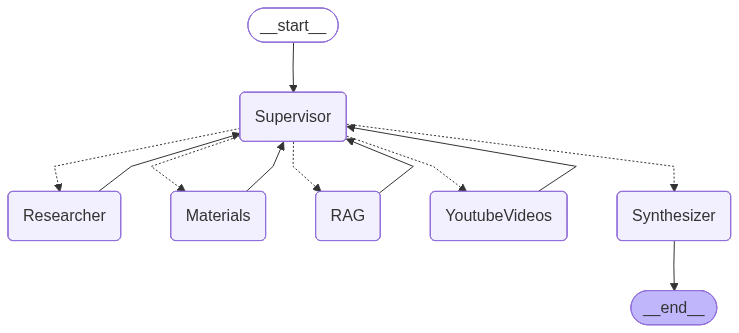

In [139]:
graph = StateGraph(State)
graph.add_node("Supervisor", Supervisor)
graph.add_node("Researcher", Researcher)
graph.add_node("Materials", Materials)    
graph.add_node("RAG", RAG)
graph.add_node("YoutubeVideos", YoutubeVideos)
graph.add_node("Synthesizer", Synthesizer)

graph.add_edge(START, "Supervisor")
graph.add_conditional_edges("Supervisor", AgentSelection, {"Researcher" : "Researcher", "RAG" : "RAG", "YoutubeVideos" : "YoutubeVideos", "Materials" : "Materials", "Synthesizer" : "Synthesizer"})
graph.add_edge("Researcher", "Supervisor")
graph.add_edge("RAG", "Supervisor")
graph.add_edge("Materials", "Supervisor")
graph.add_edge("YoutubeVideos", "Supervisor")
graph.add_edge("Synthesizer", END)

MainGraph = graph.compile()

MainGraph



In [140]:
MainGraph.invoke({'goal' : "Self-attention"})

Self-attention
Supervisor Completed ✅
next ----> 1


RateLimitError: Error code: 429 - {'error': {'message': 'Rate limit reached for model `llama-3.3-70b-versatile` in organization `org_01jyybzh50ft2tazyyre8nf93j` service tier `on_demand` on tokens per day (TPD): Limit 100000, Used 99518, Requested 2071. Please try again in 22m52.896s. Need more tokens? Upgrade to Dev Tier today at https://console.groq.com/settings/billing', 'type': 'tokens', 'code': 'rate_limit_exceeded'}}

In [105]:
# # FOR THE SUPERVISOR NODE
# def Supervisor(state : State):
#     goal = state['goal']
#     researcher = state.get('research_agent', [{'sub_goal': 'explain self sttention clearly',
#  'agent_plan': [{'id': 1,
#    'goal': 'Introduce the concept of attention in neural networks and its purpose in focusing on relevant information.',
#    'research_flag': False},
#   {'id': 2,
#    'goal': 'Explain the query‑key‑value formulation that underlies self‑attention, defining each component and how they interact.',
#    'research_flag': False},
#   {'id': 3,
#    'goal': 'Show a step‑by‑step numerical example of computing attention scores, applying the softmax, and obtaining the weighted sum.',
#    'research_flag': False},
#   {'id': 4,
#    'goal': 'Describe multi‑head attention, why multiple heads are used, and how their outputs are concatenated and projected.',
#    'research_flag': False},
#   {'id': 5,
#    'goal': 'Summarize the advantages of self‑attention (parallelism, long‑range dependencies) and its role in Transformer architectures.',
#    'research_flag': False}],
#  'agent_explain': [HumanMessage(content='Attention is a mechanism that lets a neural network dynamically weigh different parts of its input when producing an output, rather than treating every element as equally important. By computing a set of relevance scores (often called “attention weights”) between a query representation and a collection of key–value pairs derived from the data, the model can amplify information that is most pertinent to the current task and suppress what is less useful. This selective focus enables networks—especially sequence models like Transformers—to capture long‑range dependencies, handle variable‑length inputs, and produce more accurate predictions, because each decision is informed primarily by the pieces of data that matter most in that context. In short, attention helps neural networks concentrate on the relevant information while ignoring the irrelevant.', additional_kwargs={}, response_metadata={}, id='6123b968-8ad6-4ae5-a23c-1ffbf2621012'),
#   HumanMessage(content='Self‑attention computes a new representation for each token by letting that token **query** information from all other tokens (including itself).  \nThe whole operation can be written as a series of matrix multiplications that involve three learned projections of the input sequence:\n\n\\[\n\\begin{aligned}\nQ &= X\\,W_Q \\qquad &\\text{(queries)}\\\\\nK &= X\\,W_K \\qquad &\\text{(keys)}\\\\\nV &= X\\,W_V \\qquad &\\text{(values)}\n\\end{aligned}\n\\]\n\n* **\\(X\\)** – the input matrix of shape \\((n, d_{\\text{model}})\\), where \\(n\\) is the number of tokens (or positions) and \\(d_{\\text{model}}\\) is the hidden dimension.  \n* **\\(W_Q, W_K, W_V\\)** – learned weight matrices of shape \\((d_{\\text{model}}, d_k)\\) (or \\((d_{\\text{model}}, d_v)\\) for values). They linearly project each token into three distinct sub‑spaces:\n  * **Query vectors** \\(q_i\\) describe what token \\(i\\) is looking for.\n  * **Key vectors** \\(k_j\\) describe what each token \\(j\\) offers.\n  * **Value vectors** \\(v_j\\) hold the actual content that will be passed on if a token is attended to.\n\n---\n\n### Interaction: attention scores and weighted sum  \n\nFor every pair of tokens \\((i, j)\\) we compute a similarity score by the dot product of their query and key:\n\n\\[\n\\alpha_{ij} = \\frac{q_i \\cdot k_j}{\\sqrt{d_k}}\n\\]\n\nThe division by \\(\\sqrt{d_k}\\) (the **scaling factor**) prevents the dot‑product magnitude from growing with the dimensionality, which would push the softmax into regions with extremely small gradients.\n\nThese raw scores are turned into a probability distribution over the \\(n\\) tokens with a softmax:\n\n\\[\n\\tilde{\\alpha}_{ij}= \\operatorname{softmax}_j(\\alpha_{ij}) \n= \\frac{\\exp(\\alpha_{ij})}{\\sum_{l=1}^{n}\\exp(\\alpha_{il})}\n\\]\n\n\\(\\tilde{\\alpha}_{ij}\\) tells how much token \\(i\\) should attend to token \\(j\\).\n\nFinally, each token’s output is the weighted sum of the value vectors, using the attention weights:\n\n\\[\n\\text{output}_i = \\sum_{j=1}^{n} \\tilde{\\alpha}_{ij}\\, v_j\n\\]\n\nIn matrix form this becomes the familiar **scaled dot‑product attention**:\n\n\\[\n\\text{Attention}(Q,K,V)=\\operatorname{softmax}\\!\\left(\\frac{QK^{\\top}}{\\sqrt{d_k}}\\right)V\n\\]\n\n---\n\n### Summary of components  \n\n| Symbol | Meaning | Shape (for one head) |\n|--------|---------|----------------------|\n| \\(X\\) | Input token embeddings | \\((n, d_{\\text{model}})\\) |\n| \\(W_Q, W_K, W_V\\) | Linear projection matrices (learned) | \\((d_{\\text{model}}, d_k)\\) or \\((d_{\\text{model}}, d_v)\\) |\n| \\(Q, K, V\\) | Projected queries, keys, values | \\((n, d_k)\\) (or \\(d_v\\) for \\(V\\)) |\n| \\(QK^{\\top}\\) | Pairwise similarity matrix | \\((n, n)\\) |\n| \\(\\operatorname{softmax}(\\cdot)\\) | Normalizes similarities into attention weights | \\((n, n)\\) |\n| \\( \\text{Attention}(Q,K,V) \\) | Final output after weighting values | \\((n, d_v)\\) |\n\nThe query‑key‑value formulation thus lets each position gather information from the whole sequence, with the learned projections determining **what** is queried, **what** can be matched, and **what** is transmitted. This mechanism is the core of the Transformer’s self‑attention layer.', additional_kwargs={}, response_metadata={}, id='957f3ebb-cbc0-4e82-8300-6678ddd80cc5'),
#   HumanMessage(content='**Step‑by‑step numerical example of scaled dot‑product attention**\n\nWe will work with a tiny toy example so every arithmetic step can be shown clearly.\n\n| dimension | 2 (so vectors are 2‑D) |\n|----------|------------------------|\n| number of keys / values | 3 (\u202f\\(k_1,k_2,k_3\\)\u202f) |\n| scaling factor | \\(\\frac{1}{\\sqrt{d}}\\) with \\(d=2\\) → \\(\\frac{1}{\\sqrt{2}}\\approx0.7071\\) |\n\n---\n\n### 1. Define the query, keys and values  \n\n\\[\n\\mathbf{q}= \\begin{bmatrix}1 \\\\ 0\\end{bmatrix},\n\\qquad\n\\mathbf{k}_1=\\begin{bmatrix}1 \\\\ 1\\end{bmatrix},\n\\quad\n\\mathbf{k}_2=\\begin{bmatrix}0 \\\\ 2\\end{bmatrix},\n\\quad\n\\mathbf{k}_3=\\begin{bmatrix} -1 \\\\ 0\\end{bmatrix}\n\\]\n\n\\[\n\\mathbf{v}_1=\\begin{bmatrix}1 \\\\ 2\\end{bmatrix},\n\\quad\n\\mathbf{v}_2=\\begin{bmatrix}0 \\\\ 1\\end{bmatrix},\n\\quad\n\\mathbf{v}_3=\\begin{bmatrix}2 \\\\ 0\\end{bmatrix}\n\\]\n\n---\n\n### 2. Compute raw attention scores (dot products)\n\n\\[\ns_i = \\mathbf{q}^\\top \\mathbf{k}_i\n\\]\n\n| \\(i\\) | \\(\\mathbf{q}^\\top\\mathbf{k}_i\\) | raw score \\(s_i\\) |\n|------|-------------------------------|-------------------|\n| 1 | \\([1,0]\\cdot[1,1]=1\\) | \\(s_1 = 1\\) |\n| 2 | \\([1,0]\\cdot[0,2]=0\\) | \\(s_2 = 0\\) |\n| 3 | \\([1,0]\\cdot[-1,0]=-1\\) | \\(s_3 = -1\\) |\n\n---\n\n### 3. Scale the scores  \n\n\\[\n\\hat{s}_i = \\frac{s_i}{\\sqrt{d}} = s_i \\times 0.7071\n\\]\n\n| \\(i\\) | \\(\\hat{s}_i\\) |\n|------|--------------|\n| 1 | \\(1 \\times 0.7071 = 0.7071\\) |\n| 2 | \\(0 \\times 0.7071 = 0\\) |\n| 3 | \\(-1 \\times 0.7071 = -0.7071\\) |\n\n---\n\n### 4. Apply the softmax to obtain attention weights  \n\n\\[\n\\alpha_i = \\frac{e^{\\hat{s}_i}}{\\sum_{j=1}^{3} e^{\\hat{s}_j}}\n\\]\n\nFirst compute the exponentials:\n\n| \\(i\\) | \\(e^{\\hat{s}_i}\\) |\n|------|-------------------|\n| 1 | \\(e^{0.7071}\\approx 2.028\\) |\n| 2 | \\(e^{0}\\;=1\\) |\n| 3 | \\(e^{-0.7071}\\approx 0.493\\) |\n\nSum of exponentials: \\(2.028 + 1 + 0.493 = 3.521\\).\n\nNow the normalized weights:\n\n| \\(i\\) | \\(\\alpha_i = \\frac{e^{\\hat{s}_i}}{3.521}\\) |\n|------|-------------------------------------------|\n| 1 | \\(\\frac{2.028}{3.521}\\approx0.576\\) |\n| 2 | \\(\\frac{1}{3.521}\\approx0.284\\) |\n| 3 | \\(\\frac{0.493}{3.521}\\approx0.140\\) |\n\nCheck: \\(0.576+0.284+0.140 \\approx 1.000\\).\n\n---\n\n### 5. Compute the weighted sum of the values  \n\n\\[\n\\mathbf{o}= \\sum_{i=1}^{3} \\alpha_i \\mathbf{v}_i\n\\]\n\nDo the multiplication for each component:\n\n*For the first component*  \n\n\\[\no_1 = 0.576\\cdot 1 \\;+\\; 0.284\\cdot 0 \\;+\\; 0.140\\cdot 2\n     = 0.576 + 0 + 0.280 = 0.856\n\\]\n\n*For the second component*  \n\n\\[\no_2 = 0.576\\cdot 2 \\;+\\; 0.284\\cdot 1 \\;+\\; 0.140\\cdot 0\n     = 1.152 + 0.284 + 0 = 1.436\n\\]\n\nThus the final attention output vector is\n\n\\[\n\\boxed{\\mathbf{o}= \\begin{bmatrix}0.856 \\\\ 1.436\\end{bmatrix}}\n\\]\n\n---\n\n### Recap of the whole pipeline\n\n1. **Dot‑product** of query with each key → raw scores \\([1,0,-1]\\).  \n2. **Scale** by \\(1/\\sqrt{d}\\) → \\([0.7071,0,-0.7071]\\).  \n3. **Softmax** → attention weights \\([0.576,0.284,0.140]\\).  \n4. **Weighted sum** of the value vectors using those weights → output \\([0.856,1.436]\\).\n\nThis tiny example illustrates every arithmetic operation that a transformer‑style attention head performs on a single query.', additional_kwargs={}, response_metadata={}, id='dc61e8a5-53d7-4a18-8d7f-f018461e7cb6'),
#   HumanMessage(content='**Multi‑head attention**\n\nIn a transformer, attention computes a weighted sum of value vectors\u202f\\(V\\) for each query vector\u202f\\(Q\\), where the weights come from the similarity of queries to keys\u202f\\(K\\).  Multi‑head attention extends the basic (single‑head) scaled‑dot‑product attention by running several attention mechanisms in parallel, each on a different linear projection of the same inputs.\n\n---\n\n### How it works  \n\n1. **Linear projections** – For each head\u202f\\(h\\) (there are \\(H\\) heads) we learn three projection matrices  \n   \\[\n   W_i^{Q_h}\\in\\mathbb{R}^{d_{\\text{model}}\\times d_k},\\quad\n   W_i^{K_h}\\in\\mathbb{R}^{d_{\\text{model}}\\times d_k},\\quad\n   W_i^{V_h}\\in\\mathbb{R}^{d_{\\text{model}}\\times d_v}\n   \\]\n   and compute  \n   \\[\n   Q_h = XW_i^{Q_h},\\qquad\n   K_h = XW_i^{K_h},\\qquad\n   V_h = XW_i^{V_h},\n   \\]\n   where \\(X\\) is the input (e.g., word embeddings) and \\(d_k=d_v=d_{\\text{model}}/H\\).\n\n2. **Scaled‑dot‑product attention per head** – Each head independently performs  \n   \\[\n   \\text{Attention}(Q_h,K_h,V_h)=\\operatorname{softmax}\\!\\Big(\\frac{Q_hK_h^{\\top}}{\\sqrt{d_k}}\\Big)V_h .\n   \\]\n\n3. **Concatenation** – The \\(H\\) output matrices \\(\\text{head}_h\\) (each of shape \\(\\text{seq\\_len}\\times d_v\\)) are concatenated along the feature dimension:  \n   \\[\n   \\text{Concat}(\\text{head}_1,\\dots,\\text{head}_H)\\in\\mathbb{R}^{\\text{seq\\_len}\\times (H d_v)} .\n   \\]\n\n4. **Final linear projection** – A learned matrix \\(W^O\\in\\mathbb{R}^{(H d_v)\\times d_{\\text{model}}}\\) projects the concatenated result back to the model dimension:  \n   \\[\n   \\text{MultiHead}(X)=\\text{Concat}(\\text{head}_1,\\dots,\\text{head}_H)W^O .\n   \\]\n\n---\n\n### Why use multiple heads?\n\n* **Capture diverse relationships** – Each head works on a different sub‑space of the input (different \\(W^{Q,K,V}\\) matrices). This lets the model attend to information at different positions, scales, or representation aspects simultaneously (e.g., syntax vs. semantics).\n* **Increase representational capacity** – Splitting the total dimensionality \\(d_{\\text{model}}\\) into several smaller heads gives the network more “attention filters” without increasing the total computational cost dramatically; each head processes a lower‑dimensional space, keeping the per‑head cost modest.\n* **Stabilize learning** – With many heads the gradients are spread across several projection paths, which can improve optimization and reduce the risk that a single attention pattern dominates.\n\nIn short, multi‑head attention runs several parallel attention operations, concatenates their results, and linearly projects back to the original model dimension, enabling the model to jointly attend to information from different representation sub‑spaces.', additional_kwargs={}, response_metadata={}, id='17d8ce0a-dfa6-487c-a082-80dde9c0debc'),
#   HumanMessage(content='Self‑attention is the core operation that lets Transformers replace recurrence and convolution with a fully connected, content‑based interaction among all positions in a sequence.\n\n**Why it matters**\n\n1. **Parallelism** – Each token’s attention scores are computed from the same set of query, key and value matrices, so the whole attention map can be built with matrix multiplications that run on GPUs/TPUs in a single forward pass. Unlike recurrent networks, there is no step‑by‑step dependency, so training and inference scale with \\(O(L)\\) depth rather than \\(O(L)\\) time, where \\(L\\) is sequence length.\n\n2. **Long‑range dependencies** – The attention weight between any two positions is a direct dot‑product of their representations. Consequently, information can travel from token\u202fi to token\u202fj in one layer, irrespective of how far apart they are. Stacking a modest number of layers lets the model capture relationships across the entire sequence without the vanishing‑gradient problems that plague RNNs.\n\n**Role in Transformer architectures**\n\n- **Building the encoder/decoder blocks** – Each block contains a multi‑head self‑attention sub‑layer (plus a feed‑forward sub‑layer). Multi‑head attention lets the model attend to different subspaces simultaneously, enriching the representation.\n- **Facilitating cross‑attention** – In the decoder, self‑attention first processes previously generated tokens, then a separate cross‑attention sub‑layer attends to encoder outputs, reusing the same attention machinery.\n- **Enabling positional encoding** – Because self‑attention is permutation‑invariant, explicit positional encodings are added to inject order information, after which attention can freely combine tokens based on content.\n\nOverall, self‑attention provides the computational efficiency (full parallelism) and expressive power (direct, unrestricted connections) that make Transformers the dominant architecture for language, vision, and many other sequence‑modeling tasks.', additional_kwargs={}, response_metadata={}, id='0f065a82-c959-490f-b4e8-d92e76b15773')]}])
#     researcher = []
#     print(researcher)
#     print(goal)
#     prompt = ChatPromptTemplate.from_messages([
#     ("system","""
#       You are a supervisor agent for an AI Tutor.

#       You have the following specialized worker agents:

#       1 → research_agent
#          - Performs deep research on a topic using LLM knowledge and research tools.

#       2 → Youtube_agent
#          - Finds relevant YouTube videos and summarizes one of them.

#       3 → END
#          - Used when no worker agent is required.


#       --------------------------------
#       WORK DONE BY AGENTS SO FAR
#       --------------------------------

#       Researcher : {researcher_work}
#       YoutubeAgent : []

#       If [] appears, the agent has NOT been used yet.


#       --------------------------------
#       YOUR JOB
#       --------------------------------

#       Your task is to decide which ONE agent should act next.

#       You must choose only ONE of:
#       research_agent
#       Youtube_agent
#       END


#       --------------------------------
#       DECISION PROCESS
#       --------------------------------

#       Follow this reasoning:

#       1. Understand the user goal.
#       2. Decide if the goal requires:
#          - deep knowledge or research → Researcher
#          - video explanation → YoutubeAgent
#       3. If neither research nor video is required → choose END.


#       --------------------------------
#       IMPORTANT RULES
#       --------------------------------

#       1. Only call an agent if it is truly required.
#       2. Do NOT call agents unnecessarily.
#       3. If the task can already be answered → choose END.
#       4. If an agent already has work (not []), do NOT call it again.
#       5. Only one agent may be chosen at a time.


#       --------------------------------
#       OUTPUT FORMAT
#       --------------------------------

#       {format}

#       If END is selected:

#       sub_goal = "No further action required"
#       """
#       ),
#       ("human", "Goal/Query from user: {goal}")
#       ]).partial(
#          format=sub_goal_schema.get_format_instructions(),
#          researcher_work= []
#       )
#     # Generate the title for it
#     chain = prompt | llm
#     response = chain.invoke({'goal' : goal})
#     print(response.additional_kwargs['reasoning_content'])
#     state['research_agent'] = {'goal' : "wdd"}
#     return {'agent_id' : [response.id], response.agent : {'goal' : response.sub_goal}}